[*********************100%***********************]  5 of 5 completed



Доли активов в эффективном портфеле с доходностью M = 0.002:
JPM: 0.481738
JNJ: -0.403653
WMT: 0.856348
PG: 0.233613
KO: -0.168046

Сумма весов = 1.000000
Ожидаемая доходность (факт) = 0.002000
Дисперсия портфеля = 0.000137
Стандартное отклонение = 0.011687


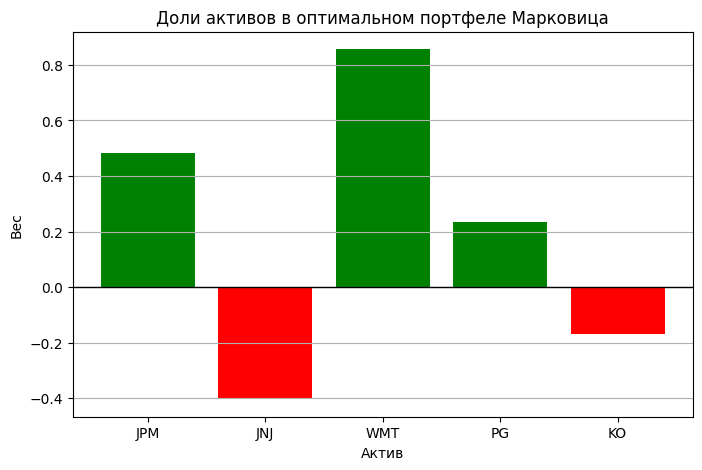

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ["JPM", "JNJ", "WMT", "PG", "KO"]

# Скачиваем данные
raw = yf.download(
    tickers,
    start="2023-01-01",
    end="2024-12-31",
    auto_adjust=False,
    actions=True,
    group_by="ticker"
)

# Расчет доходностей
returns_dict = {}
for ticker in tickers:
    price = raw[ticker]["Close"]
    dividends = raw[ticker]["Dividends"]
    r = (price.diff() + dividends) / price.shift(1)
    returns_dict[ticker] = r

returns = pd.DataFrame(returns_dict).dropna()

# Ожидаемые доходности и ковариация
E = returns.mean().values
C = returns.cov().values
C_inv = np.linalg.inv(C)
n = len(tickers)
one = np.ones(n)

# Параметры для задачи Марковица
alpha = E @ C_inv @ E
beta = one @ C_inv @ E
gamma = one @ C_inv @ one
delta = alpha * gamma - beta * beta

# Целевая доходность
M = 0.002

# Оптимальные веса
v1 = -(gamma / delta) * E + (beta / delta) * one
v2 = (beta / delta) * E - (alpha / delta) * one
x_opt = -M * (C_inv @ v1) - (C_inv @ v2)

print(f"\nДоли активов в эффективном портфеле с доходностью M = {M}:")
for ticker, w in zip(tickers, x_opt):
    print(f"{ticker}: {w:.6f}")

print(f"\nСумма весов = {x_opt.sum():.6f}")
print(f"Ожидаемая доходность (факт) = {x_opt @ E:.6f}")
print(f"Дисперсия портфеля = {x_opt.T @ C @ x_opt:.6f}")
print(f"Стандартное отклонение = {np.sqrt(x_opt.T @ C @ x_opt):.6f}")

# График
plt.figure(figsize=(8,5))
colors = ["green" if w > 0 else "red" for w in x_opt]
plt.bar(tickers, x_opt, color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.title("Доли активов в оптимальном портфеле Марковица")
plt.ylabel("Вес")
plt.xlabel("Актив")
plt.grid(axis="y")
plt.show()